Do imports.

In [1]:
import numpy as np
from qpsolvers import solve_qp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
import sympy as sym

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)

Define the problem.

In [2]:
# Time step
T = 0.1

# Time horizon
N = 100

# Dynamics (double integrator - exact discretization with time step T)
A = np.array([[1., T], [0., 1.]])
B = np.array([[T**2 / 2], [T]])

# Weights in quadratic running/terminal cost
Q = np.diag([3., 2.])
R = np.diag([1.])

Trajectory optimization for a specific initial condition.

In [3]:
# Initial condition
xbar_0 = np.array([1., 2.])

# Length of state and input
n_x = 2
n_u = 1

# Functions to help with indexing
def x_idx(i):
    return i * (n_x + n_u)
def u_idx(i):
    return i * (n_x + n_u) + n_x

# QP cost
P_qp = np.zeros((N * (n_x + n_u) + n_x, N * (n_x + n_u) + n_x))
q_qp = np.zeros(N * (n_x + n_u) + n_x)
for i in range(N):
    P_qp[x_idx(i):u_idx(i), x_idx(i):u_idx(i)] = Q
    P_qp[u_idx(i):x_idx(i + 1), u_idx(i):x_idx(i + 1)] = R
P_qp[x_idx(N):u_idx(N), x_idx(N):u_idx(N)] = Q

# QP equality constraint 
A_qp = np.zeros(((N + 1) * n_x, N * (n_x + n_u) + n_x))
b_qp = np.zeros((N + 1) * n_x)
A_qp[0:n_x, x_idx(0):u_idx(0)] = np.eye(n_x)
for i in range(N):
    A_qp[((i + 1) * n_x):((i + 2) * n_x), x_idx(i):u_idx(i)] = -A
    A_qp[((i + 1) * n_x):((i + 2) * n_x), u_idx(i):x_idx(i + 1)] = -B
    A_qp[((i + 1) * n_x):((i + 2) * n_x), x_idx(i + 1):u_idx(i + 1)] = np.eye(n_x)
b_qp[0:n_x] = xbar_0

# QP solution
z = solve_qp(P=P_qp, q=q_qp, A=A_qp, b=b_qp, solver='proxqp', verbose=False, eps_abs=1e-10, eps_rel=1e-10)
x_opt = np.vstack([z[x_idx(i):u_idx(i)] for i in range(N + 1)])
u_opt = np.vstack([z[u_idx(i):x_idx(i + 1)] for i in range(N)])

Policy optimization for *any* initial condition.

In [4]:
# Optimal cost-to-go (backward pass)
P = [Q]
for n in range(N):
    P.append(Q + A.T @ P[-1] @ A - A.T @ P[-1] @ B @ np.linalg.inv(B.T @ P[-1] @ B + R) @ B.T @ P[-1] @ A)
P.reverse()
P = np.array(P)

# Optimal policy (forward pass)
K = []
for n in range(N):
    K.append(np.linalg.inv(B.T @ P[n + 1] @ B + R) @ B.T @ P[n + 1] @ A)
K = np.array(K)

Do rollout of optimal policy for a specific initial condition and confirm it is the same as the optimal trajectory that we found before.

In [5]:
# Lists in which to log results
x_opt_alt = [xbar_0]
u_opt_alt = []

# Initial state
x_n = xbar_0

# Iterate over all time steps
for n in range(N):
    # Input at current time step
    u_n = - K[n] @ x_n
    u_opt_alt.append(u_n)

    # State at next time step
    x_n = A @ x_n + B @ u_n
    x_opt_alt.append(x_n)

# Collect results
u_opt_alt = np.array(u_opt_alt)
x_opt_alt = np.array(x_opt_alt)

# Compare results to what we got before
assert(np.allclose(u_opt, u_opt_alt))
assert(np.allclose(x_opt, x_opt_alt))

Look at the optimal gains

$$ K_n = \begin{bmatrix} k_{n,1} & k_{n,2} \end{bmatrix} $$

as functions of the time step $n$.

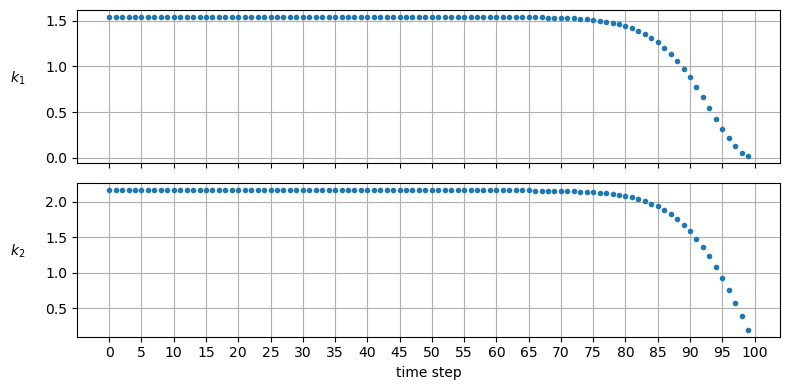

In [6]:
# Extract the two gains at each time step
n = np.array(range(N))
k_1 = np.array([K_n[0, 0] for K_n in K])
k_2 = np.array([K_n[0, 1] for K_n in K])

# Plot these gains as a function of time step
fig, (ax_1, ax_2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True, tight_layout=True)
ax_1.plot(n, k_1, '.')
ax_2.plot(n, k_2, '.')
ax_1.set_ylabel(r'$k_1$', rotation='horizontal', labelpad=20)
ax_1.grid()
ax_2.set_xticks(np.concatenate([n[::5], [n[-1] + 1]]))
ax_2.set_xlabel('time step')
ax_2.set_ylabel(r'$k_2$', rotation='horizontal', labelpad=20)
ax_2.grid()
plt.show()

Compute the steady-state gains by solving a discrete-time algebraic Riccati equation.

In [7]:
# Import solver
from scipy.linalg import solve_discrete_are

# Compute steady-state cost-to-go matrix P_ss
P_ss = solve_discrete_are(A, B, Q, R)

# Compute steady-state gain matrix K_ss
K_ss = np.linalg.inv(B.T @ P_ss @ B + R) @ B.T @ P_ss @ A

# Compare K_ss to K[0]
assert(np.allclose(K_ss, K[0]))

Show the optimal cost-to-go.

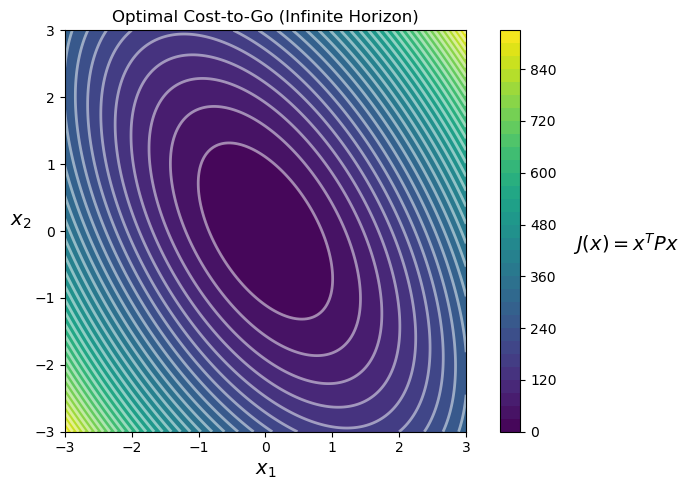

In [8]:
# Grid of states
x1 = np.linspace(-3, 3, 200)
x2 = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(x1, x2)

# Evaluate J(x) = x^T P x at each grid point
X = np.stack([X1, X2], axis=-1)  # shape (200, 200, 2)
J= np.zeros_like(X1)
for i in range(200):
    for j in range(200):
        x = X[i, j]
        J[i, j] = x.T @ P_ss @ x # <-- careful, the ".T" does nothing

# Plot
plt.figure(figsize=(8, 5))
cp = plt.contourf(X1, X2, J, levels=30, cmap='viridis')
cbar = plt.colorbar(cp)
cbar.set_label(r'$J(x) = x^T P x$', fontsize=14, rotation='horizontal', labelpad=50)
plt.contour(X1, X2, J, levels=30, colors='white', linewidths=2, alpha=0.5)
plt.xlabel(r'$x_1$', fontsize=14)
plt.ylabel(r'$x_2$', fontsize=14, rotation='horizontal', labelpad=10)
plt.title('Optimal Cost-to-Go (Infinite Horizon)')
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()